In [1]:
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.polynomial.polynomial import Polynomial
from scipy.stats import t
from scipy.stats import pearsonr
import os

In [2]:
# Load the dynamically generated results from the pipeline
results_path = os.path.join('..', 'results', 'sbpo_v3_results_with_similarities.csv')
if not os.path.exists(results_path):
    raise FileNotFoundError("Please run the full v3 pipeline (run_experiment.py then run_similarity.py) first.")

df = pd.read_csv(results_path)

# Ensure data is sorted by geographic distance
df = df.sort_values(by="Geo_Distance_km")

# Clean station names for plotting
df['Station_Name'] = df['Station'].apply(lambda x: x.split('-')[0].strip().capitalize() if '-' in x else x.split(maxsplit=1)[-1].title() if x[0].isdigit() else x.title())

# Split into RJ (Close: < 100km) and BR (Far: > 100km)
df_rj = df[df["Geo_Distance_km"] < 100].copy()
df_br = df[df["Geo_Distance_km"] >= 100].copy()

# Print shapes to verify
print(f"RJ Stations Loaded: {len(df_rj)}")
print(f"BR Stations Loaded: {len(df_br)}")

RJ Stations Loaded: 10
BR Stations Loaded: 10


In [3]:
def critical_pearson_r(n, confidence_level=99):
    alpha = 1 - (confidence_level / 100)
    df = n - 2
    t_critical = t.ppf(1 - alpha/2, df)
    return t_critical / ((t_critical**2 + df) ** 0.5), alpha

def critical_spearman_r(n, confidence_level=99):
    alpha = 1 - (confidence_level / 100)
    df = n - 2
    t_critical = t.ppf(1 - alpha/2, df)
    return t_critical / ((t_critical**2 + df) ** 0.5), alpha

# ANALISE GRAFICA BRASIL

In [4]:
# Perform Pearson correlation test for BRASIL
print("\n📊 Pearson Correlation Tests vs Transfer Loss (%) [BRASIL]")
correlation_cols = ["Catch22_Distance", "DTW_Distance", "Geo_Distance_km", "Transfer_Loss_%"]
df_clean_br = df_br.dropna(subset=correlation_cols).copy()

n_br = len(df_clean_br)
crit_r_br, alpha_br = critical_pearson_r(n_br, 95.45) # Original notebook used 95.45 for BR
print(f"Critical Pearson r (|r| >= {crit_r_br:.3f}) for α = {alpha_br:.3f}\n")

for col in ["Catch22_Distance", "DTW_Distance", "Geo_Distance_km"]:
    r, p_value = pearsonr(df_clean_br[col], df_clean_br["Transfer_Loss_%"])
    sig = "✅ significant" if abs(r) >= crit_r_br else "❌ not significant"
    print(f"Transfer_Loss_% vs {col:20s} → r = {r:+.3f}, p = {p_value:.4f} → {sig}")
    
print("\nDistance_km vs Other Variables:")
for col in ["Catch22_Distance", "DTW_Distance"]:
    r, p_value = pearsonr(df_clean_br[col], df_clean_br["Geo_Distance_km"])
    sig = "✅ significant" if abs(r) >= crit_r_br else "❌ not significant"
    print(f"Distance_km vs {col:20s} → r = {r:+.3f}, p = {p_value:.4f} → {sig}")


📊 Pearson Correlation Tests vs Transfer Loss (%) [BRASIL]
Critical Pearson r (|r| >= 0.642) for α = 0.045

Transfer_Loss_% vs Catch22_Distance     → r = +0.077, p = 0.8319 → ❌ not significant
Transfer_Loss_% vs DTW_Distance         → r = +0.768, p = 0.0095 → ✅ significant
Transfer_Loss_% vs Geo_Distance_km      → r = +0.504, p = 0.1378 → ❌ not significant

Distance_km vs Other Variables:
Distance_km vs Catch22_Distance     → r = -0.245, p = 0.4946 → ❌ not significant
Distance_km vs DTW_Distance         → r = +0.387, p = 0.2698 → ❌ not significant


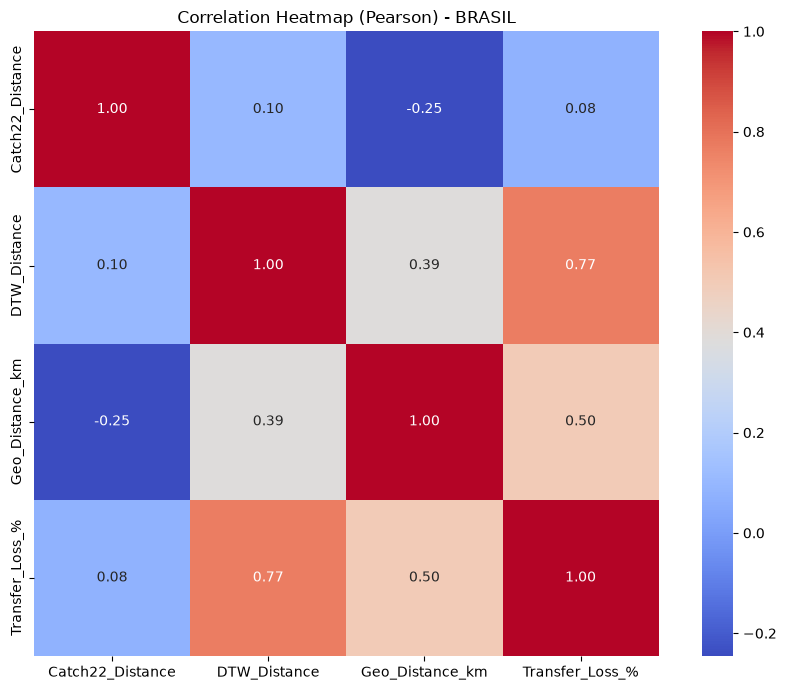

In [5]:
# HEAT MAP - ANALISE GRAFICA BRASIL
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean_br[correlation_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Pearson) - BRASIL")
plt.tight_layout()
plt.show()

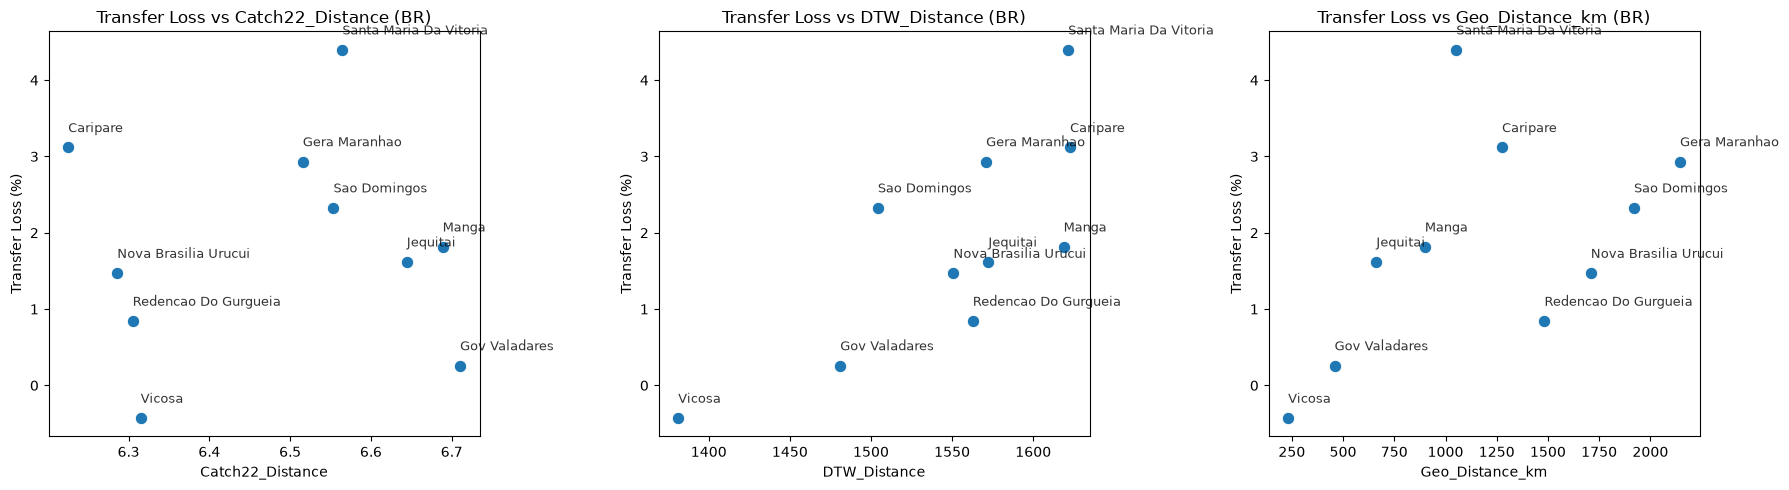

In [6]:
# Scatterplots vs Transfer Loss (%) - BRASIL
metrics = ["Catch22_Distance", "DTW_Distance", "Geo_Distance_km"]
plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df_clean_br, x=metric, y="Transfer_Loss_%", s=80)
    for _, row in df_clean_br.iterrows():
        plt.text(row[metric], row["Transfer_Loss_%"] + 0.2, row["Station_Name"], fontsize=9, alpha=0.8)
    plt.xlabel(metric)
    plt.ylabel("Transfer Loss (%)")
    plt.title(f"Transfer Loss vs {metric} (BR)")
plt.tight_layout()
plt.show()

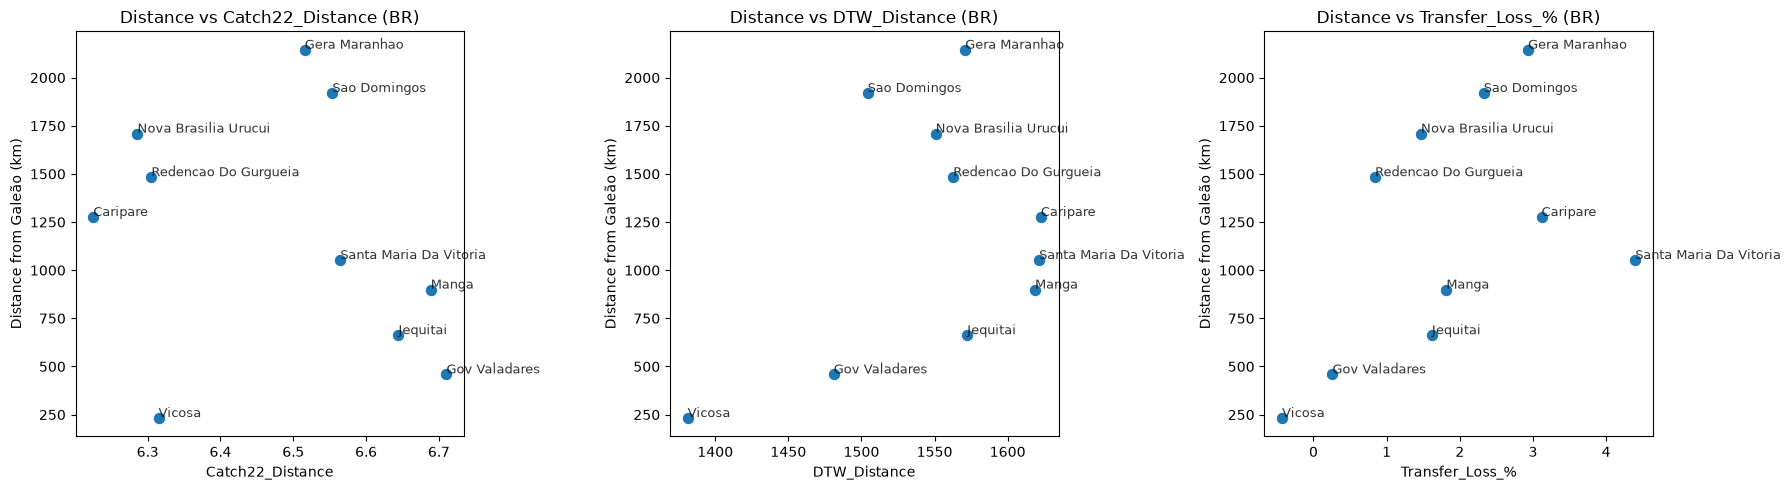

In [7]:
# Scatterplots vs Distance - BRASIL
x_metrics = ["Catch22_Distance", "DTW_Distance", "Transfer_Loss_%"]
plt.figure(figsize=(18, 5))
for i, metric in enumerate(x_metrics):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df_clean_br, x=metric, y="Geo_Distance_km", s=80)
    for _, row in df_clean_br.iterrows():
        plt.text(row[metric], row["Geo_Distance_km"] + 5, row["Station_Name"], fontsize=9, alpha=0.8)
    plt.xlabel(metric)
    plt.ylabel("Distance from Galeão (km)")
    plt.title(f"Distance vs {metric} (BR)")
plt.tight_layout()
plt.show()

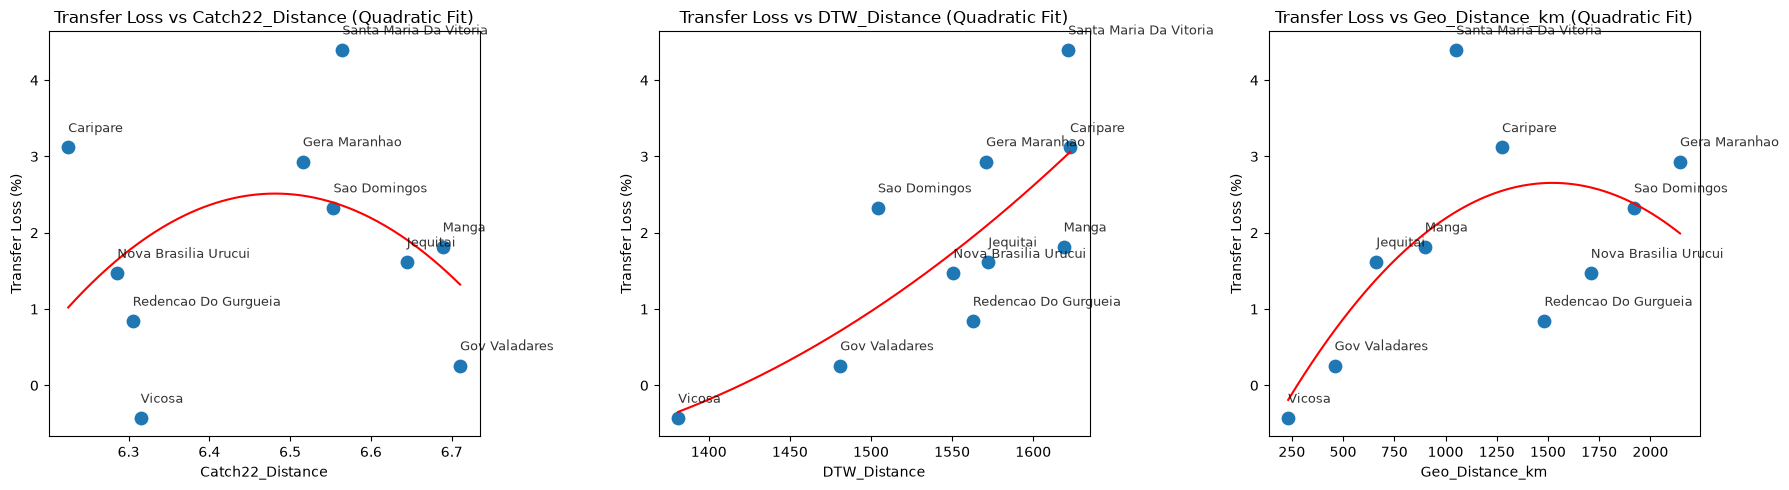

In [8]:
# TREND LINE - BRASIL (Quadratic Fit)
plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    x = df_clean_br[metric]
    y = df_clean_br["Transfer_Loss_%"]
    plt.scatter(x, y, s=80)
    p = Polynomial.fit(x, y, deg=2)
    x_seq = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_seq, p(x_seq), color="red")
    for _, row in df_clean_br.iterrows():
        plt.text(row[metric], row["Transfer_Loss_%"] + 0.2, row["Station_Name"], fontsize=9, alpha=0.8)
    plt.xlabel(metric)
    plt.ylabel("Transfer Loss (%)")
    plt.title(f"Transfer Loss vs {metric} (Quadratic Fit)")
plt.tight_layout()
plt.show()

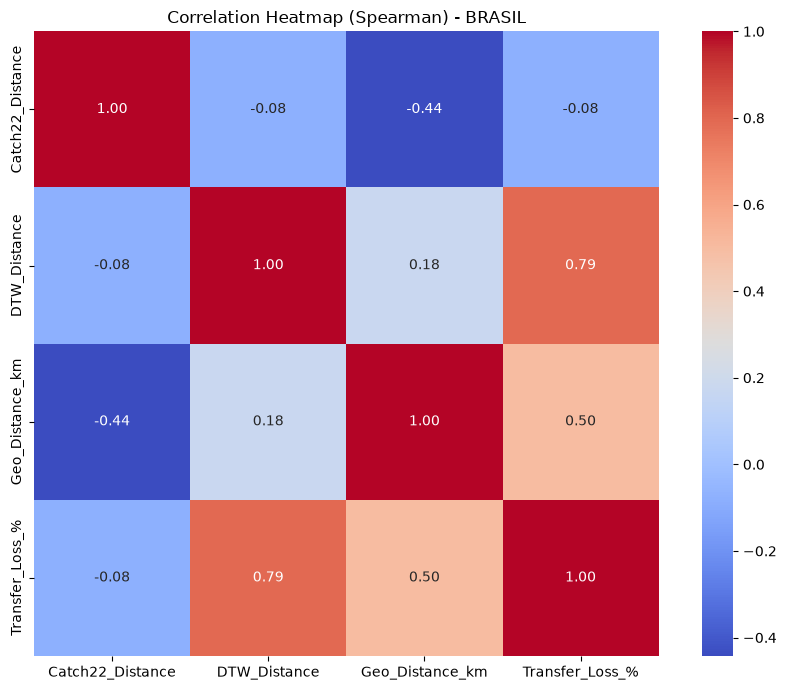

Critical Spearman's rank r for n=10 and confidence level=99%: 0.765


In [9]:
# HEAT MAP SPEARMAN - NAO LINEAR - BRASIL
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean_br[correlation_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Spearman) - BRASIL")
plt.tight_layout()
plt.show()

crit_s_br, alpha_s_br = critical_spearman_r(n_br, 99)
print(f"Critical Spearman's rank r for n={n_br} and confidence level=99%: {crit_s_br:.3f}")

# ANALISE GRAFICA RIO DE JANEIRO (RJ)

In [10]:
# MAPA DINAMICO - RJ TARGETS
galeao_coords = [-22.8089, -43.2436]
m = folium.Map(location=[-22.9, -43.3], zoom_start=11)

# Add Galeao (Source)
folium.Marker(location=galeao_coords, popup="Galeão (Source)", icon=folium.Icon(color="red")).add_to(m)

# Add all RJ Target Stations dynamically
max_dist_station = None
max_dist = -1

for _, row in df_rj.iterrows():
    loc = [row['Target_Lat'], row['Target_Lon']]
    folium.Marker(location=loc, popup=row['Station_Name']).add_to(m)
    
    if row['Geo_Distance_km'] > max_dist:
        max_dist = row['Geo_Distance_km']
        max_dist_station = row

# Highlight max distance
if max_dist_station is not None:
    folium.PolyLine(
        [galeao_coords, [max_dist_station['Target_Lat'], max_dist_station['Target_Lon']]],
        color="red", weight=3, tooltip=f"Max Distance: Galeão ↔ {max_dist_station['Station_Name']}"
    ).add_to(m)

m

In [11]:
# Perform Pearson correlation test for RJ
print("\n📊 Pearson Correlation Tests vs Transfer Loss (%) [RJ]")
df_clean_rj = df_rj.dropna(subset=correlation_cols).copy()

n_rj = len(df_clean_rj)
crit_r_rj, alpha_rj = critical_pearson_r(n_rj, 99) # Original notebook used 99 for RJ
print(f"Critical Pearson r (|r| >= {crit_r_rj:.3f}) for α = {alpha_rj:.3f}\n")

for col in ["Catch22_Distance", "DTW_Distance", "Geo_Distance_km"]:
    r, p_value = pearsonr(df_clean_rj[col], df_clean_rj["Transfer_Loss_%"])
    sig = "✅ significant" if abs(r) >= crit_r_rj else "❌ not significant"
    print(f"Transfer_Loss_% vs {col:20s} → r = {r:+.3f}, p = {p_value:.4f} → {sig}")
    
print("\nDistance_km vs Other Variables:")
for col in ["Catch22_Distance", "DTW_Distance"]:
    r, p_value = pearsonr(df_clean_rj[col], df_clean_rj["Geo_Distance_km"])
    sig = "✅ significant" if abs(r) >= crit_r_rj else "❌ not significant"
    print(f"Distance_km vs {col:20s} → r = {r:+.3f}, p = {p_value:.4f} → {sig}")


📊 Pearson Correlation Tests vs Transfer Loss (%) [RJ]
Critical Pearson r (|r| >= 0.765) for α = 0.010

Transfer_Loss_% vs Catch22_Distance     → r = -0.114, p = 0.7541 → ❌ not significant
Transfer_Loss_% vs DTW_Distance         → r = -0.204, p = 0.5718 → ❌ not significant
Transfer_Loss_% vs Geo_Distance_km      → r = -0.095, p = 0.7936 → ❌ not significant

Distance_km vs Other Variables:
Distance_km vs Catch22_Distance     → r = +0.165, p = 0.6494 → ❌ not significant
Distance_km vs DTW_Distance         → r = +0.234, p = 0.5159 → ❌ not significant


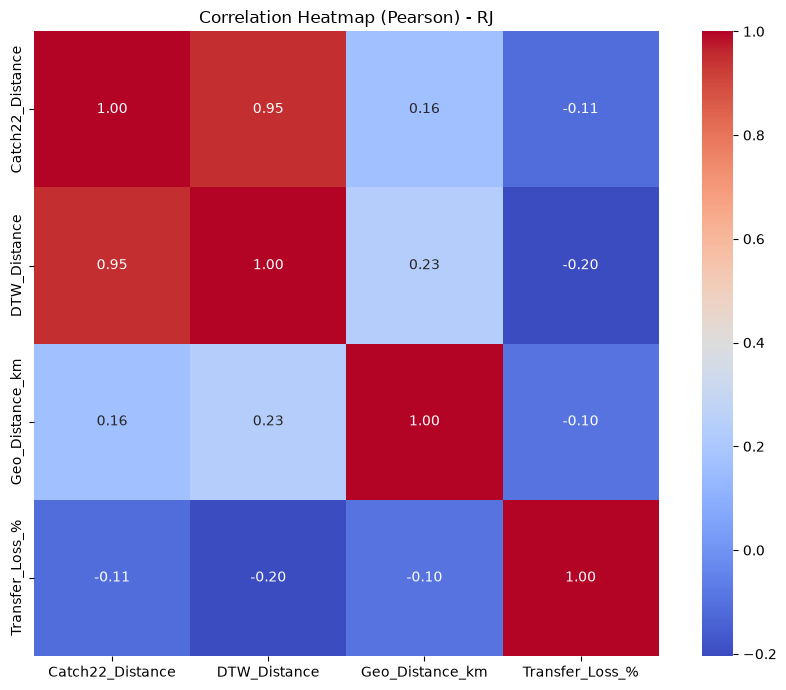

In [12]:
# HEAT MAP - ANALISE GRAFICA RJ
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean_rj[correlation_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Pearson) - RJ")
plt.tight_layout()
plt.show()

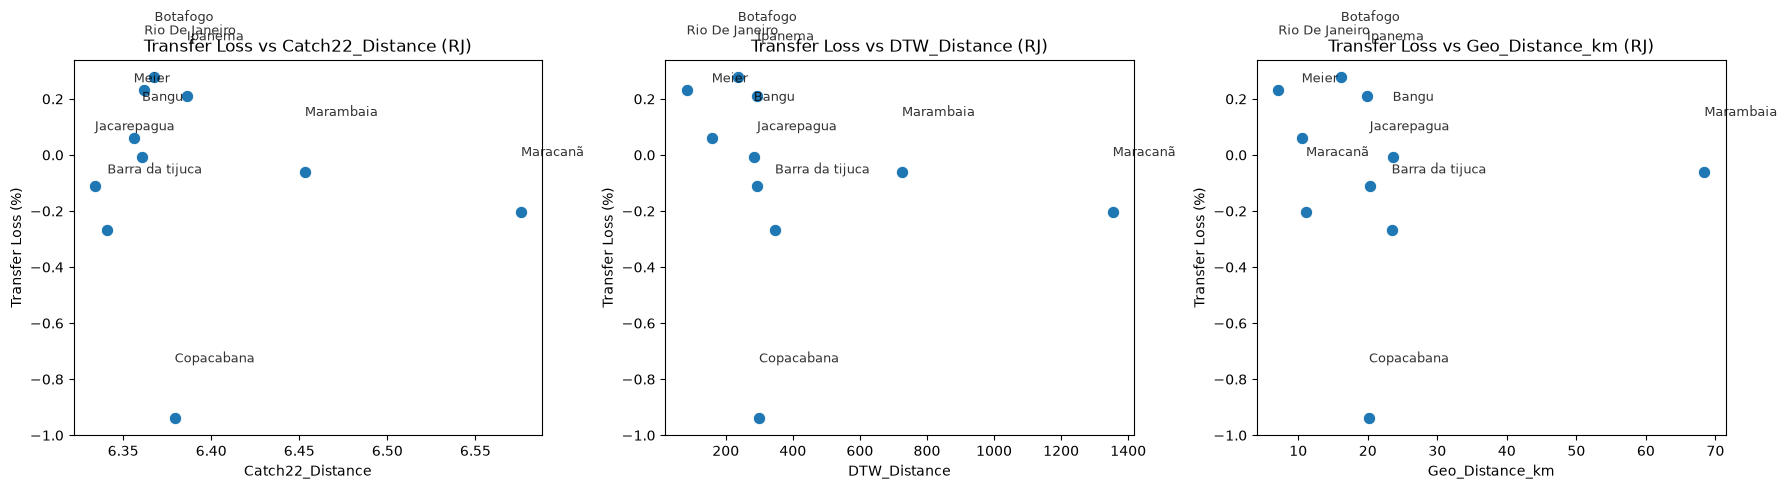

In [13]:
# Scatterplots vs Transfer Loss (%) - RJ
plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df_clean_rj, x=metric, y="Transfer_Loss_%", s=80)
    for _, row in df_clean_rj.iterrows():
        plt.text(row[metric], row["Transfer_Loss_%"] + 0.2, row["Station_Name"], fontsize=9, alpha=0.8)
    plt.xlabel(metric)
    plt.ylabel("Transfer Loss (%)")
    plt.title(f"Transfer Loss vs {metric} (RJ)")
plt.tight_layout()
plt.show()

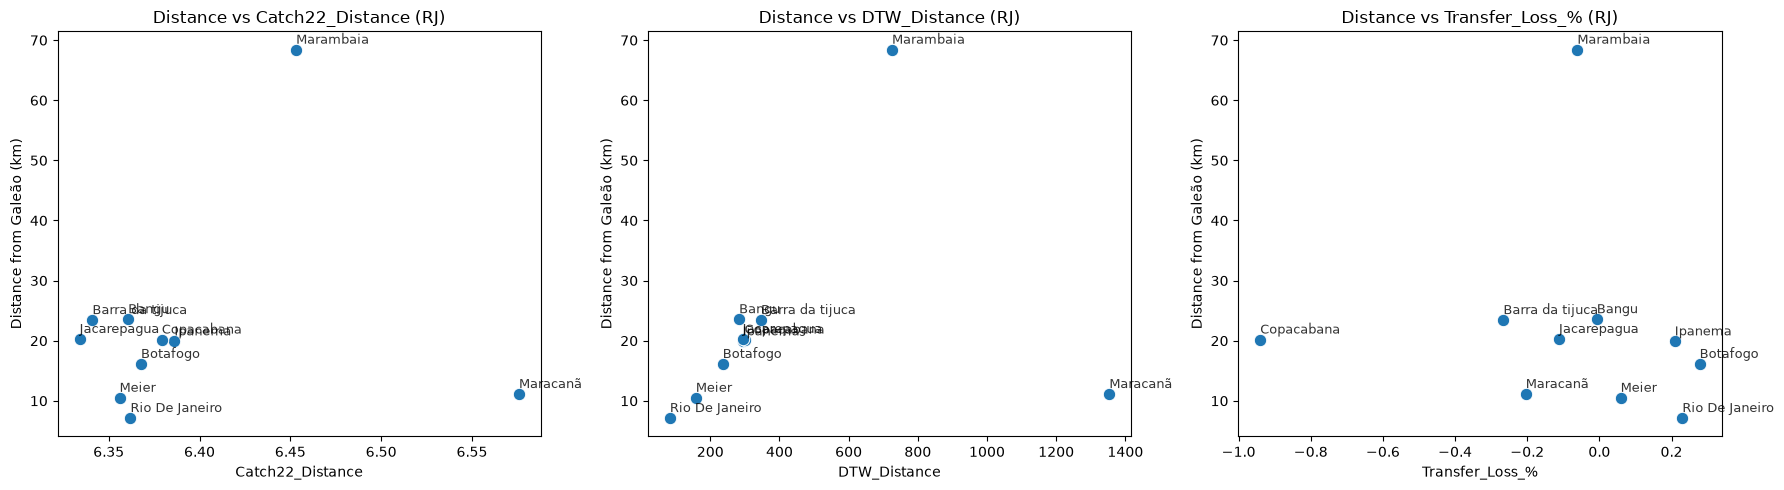

In [14]:
# Scatterplots vs Distance - RJ
plt.figure(figsize=(18, 5))
for i, metric in enumerate(x_metrics):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df_clean_rj, x=metric, y="Geo_Distance_km", s=80)
    for _, row in df_clean_rj.iterrows():
        plt.text(row[metric], row["Geo_Distance_km"] + 1, row["Station_Name"], fontsize=9, alpha=0.8)
    plt.xlabel(metric)
    plt.ylabel("Distance from Galeão (km)")
    plt.title(f"Distance vs {metric} (RJ)")
plt.tight_layout()
plt.show()

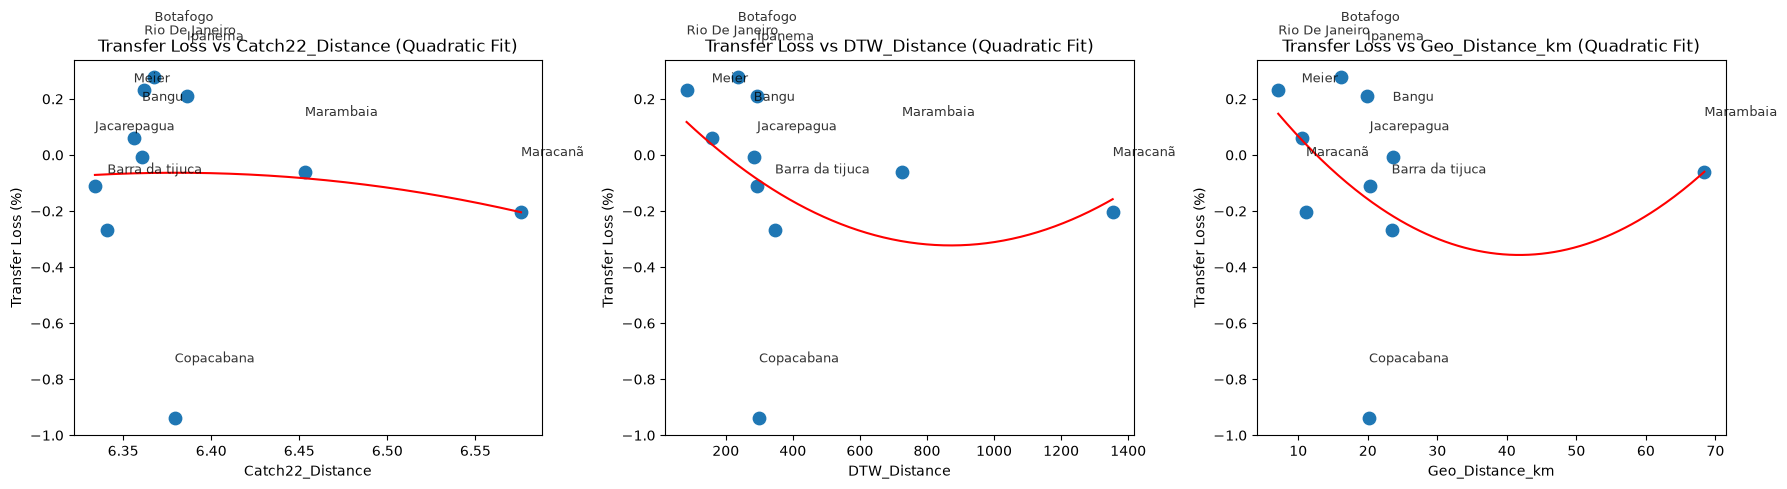

In [15]:
# TREND LINE - RJ (Quadratic Fit)
plt.figure(figsize=(18, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    x = df_clean_rj[metric]
    y = df_clean_rj["Transfer_Loss_%"]
    plt.scatter(x, y, s=80)
    p = Polynomial.fit(x, y, deg=2)
    x_seq = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_seq, p(x_seq), color="red")
    for _, row in df_clean_rj.iterrows():
        plt.text(row[metric], row["Transfer_Loss_%"] + 0.2, row["Station_Name"], fontsize=9, alpha=0.8)
    plt.xlabel(metric)
    plt.ylabel("Transfer Loss (%)")
    plt.title(f"Transfer Loss vs {metric} (Quadratic Fit)")
plt.tight_layout()
plt.show()

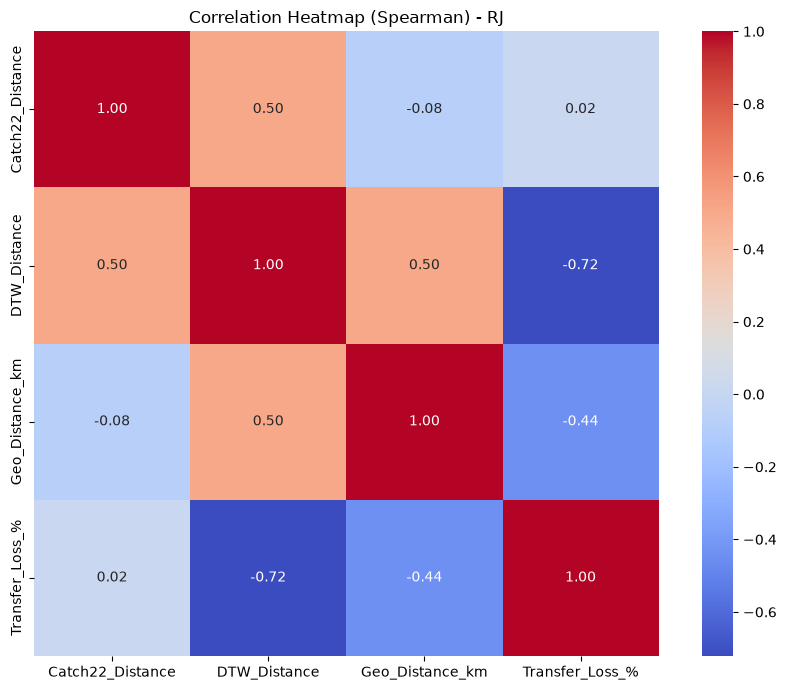

Critical Spearman's rank r for n=10 and confidence level=99%: 0.765


In [16]:
# HEAT MAP SPEARMAN - NAO LINEAR - RJ
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean_rj[correlation_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Spearman) - RJ")
plt.tight_layout()
plt.show()

crit_s_rj, alpha_s_rj = critical_spearman_r(n_rj, 99)
print(f"Critical Spearman's rank r for n={n_rj} and confidence level=99%: {crit_s_rj:.3f}")